## Conditional Graph


In [15]:
from typing import TypedDict


# --- 1. STATE ---
class State(TypedDict):
    number: int  # input number
    category: str  # set by classify_node; used by router
    result: str  # set by whichever branch runs

In [16]:
from typing import Literal


# --- 2. NODES ---
def classify_node(state: State) -> dict:
    """Decide which category the number belongs to"""
    n = state["number"]
    if n < 0:
        cat = "negative"
    elif n == 0:
        cat = "zero"
    elif n % 2 == 0:
        cat = "even"
    else:
        cat = "odd"
    print(f"[classify]  {n} → '{cat}'")
    return {"category": cat}


def negative_node(state: State) -> dict:
    return {"result": f"{state['number']} is a negative number 🔴"}


def zero_node(state: State) -> dict:
    return {"result": f"{state['number']} is exactly zero ⚪"}


def even_node(state: State) -> dict:
    return {"result": f"{state['number']} is a positive even number 🟢"}


def odd_node(state: State) -> dict:
    return {"result": f"{state['number']} is a positive odd number 🔵"}


# ─────────────────────────────────────────────────────
# 🔷 CONDITIONAL EDGE — Routing Function
# Reads state → returns the NAME of the NEXT NODE.
# The return value must match a key in the mapping dict.
# ─────────────────────────────────────────────────────
def route_by_category(state: State) -> Literal["negative", "zero", "even", "odd"]:
    return state["category"]

In [17]:
from langgraph.graph import StateGraph, START, END


# --- 3. GRAPH CONSTRUCTION ---
builder = StateGraph(State)

builder.add_node("classify", classify_node)
builder.add_node("negative", negative_node)
builder.add_node("zero", zero_node)
builder.add_node("even", even_node)
builder.add_node("odd", odd_node)

builder.add_edge(START, "classify")

# add_conditional_edges(source_node, routing_fn, {return_value: target_node})
builder.add_conditional_edges(
    "classify",
    route_by_category,
    {
        "negative": "negative",
        "zero": "zero",
        "even": "even",
        "odd": "odd",
    },
)
# All branches end at END
for branch in ["negative", "zero", "even", "odd"]:
    builder.add_edge(branch, END)

graph = builder.compile()

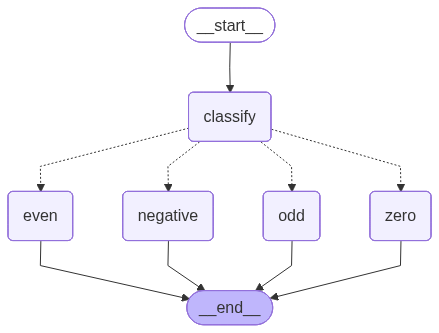

In [18]:
# --- 4. VISUALIZE ---
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
# --- 5. RUN & TEST ---
for num in [-7, 0, 4, 9, 100]:
    r = graph.invoke({"number": num, "category": "", "result": ""})
    print(f"  {r['result']}")

[classify]  -7 → 'negative'
  -7 is a negative number 🔴
[classify]  0 → 'zero'
  0 is exactly zero ⚪
[classify]  4 → 'even'
  4 is a positive even number 🟢
[classify]  9 → 'odd'
  9 is a positive odd number 🔵
[classify]  100 → 'even'
  100 is a positive even number 🟢
